In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc

In [2]:
readpath = '..' + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [28]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global d_x, d_y, cost_p_x, cost_p_y, cost_s_x, cost_e_x, cost_s_y, cost_e_y
    global d_xy_sum, d_xy, dx3, dy3, cost_xy, cost_xy_sum, costx3, costy3, len3_sum, len3sqrt
    
    readpath = '..' + os.sep
    
    data_array = data.read_data(aln, readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_cost = control_data[3]
        
    d_x = []
    d_y = []
    d_xy_sum = []
    d_xy = []
    dx3 = []
    dy3 = []
    len3_sum = []
    len3sqrt = []
    
    if case_ in ['1', '2']:
        for i in range(len(exc_1)):
            d_x.append(data.dist_right(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_low(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_right(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_low(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
    else:
        for i in range(len(exc_1)):
            d_x.append(data.dist_left(exc_1[i], inh_1[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_2)):
            d_y.append(data.dist_up(exc_2[i], inh_2[i], ext_exc, ext_inh, grid_resolution))
        for i in range(len(exc_3)):
            dx3.append(data.dist_left(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            dy3.append(data.dist_up(exc_3[i], inh_3[i], ext_exc, ext_inh, grid_resolution))
            d_xy_sum.append(dx3[-1] + dy3[-1])
            len3_sum.append( np.abs(lenx_3[i]) + np.abs(leny_3[i]) )
            d_xy.append( np.sqrt( dx3[-1]**2 + dy3[-1]**2 ) )
            len3sqrt.append( np.sqrt( lenx_3[i]**2 + leny_3[i]**2  ))
        
    cost_p_x = []
    cost_p_y = []
    cost_s_x = []
    cost_e_x = []
    cost_s_y = []
    cost_e_y = []
    
    cost_xy = []
    costx3 = []
    costy3 = []
    cost_xy_sum = []
    

    for i in range(len(d_x)):
        cost_p_x.append(cost1[i][0][0][0])
        cost_s_x.append(cost1[i][2][0][0])
        cost_e_x.append(cost1[i][1][0][0])
    for i in range(len(d_y)):
        cost_p_y.append(cost2[i][0][0][1])
        cost_s_y.append(cost2[i][2][0][1])
        cost_e_y.append(cost2[i][1][0][1])
    for i in range(len(dx3)):
        costx3.append(cost3[i][1][0][0])
        costy3.append(cost3[i][1][0][1])
        cost_xy_sum.append( costx3[-1] + costy3[-1] )
        cost_xy.append( np.sqrt( costx3[-1]**2 + costy3[-1]**2 ) )

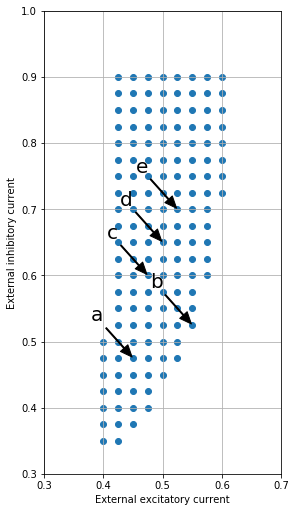

In [21]:
#FIG 1
dur = 400.
ind = [20, 35, 50, 65, 80]
str_ind = ['a', 'b', 'c', 'd', 'e']

fig1, ax = plt.subplots(constrained_layout=True, figsize = (4,7) )
ax.scatter(ext_exc, ext_inh)
ax.set_xlim(0.3, 0.7)
ax.set_ylim(0.3, 1.)

for i in range(len(ind)):
    x_ = ext_exc[ind[i]]
    y_ = ext_inh[ind[i]]
    ax.annotate(str_ind[i], xy=(x_, y_),  xycoords='data',
            xytext=(x_ - 0.05, y_ + 0.05), textcoords='data', fontsize=20,
            arrowprops=dict(facecolor='black', shrink=0.03, headwidth=10, width=1),
            horizontalalignment='right', verticalalignment='bottom',
            )
    
ax.set_xlabel("External excitatory current")
ax.set_ylabel("External inhibitory current")
    
plt.savefig( os.path.join(os.getcwd(), 'FIG_1') )

task1
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
optimal cost =  3.3312300786170534
shift by -20 ms cost =  3.331230264728989
shift by +20 ms cost =  3.3312315299504633


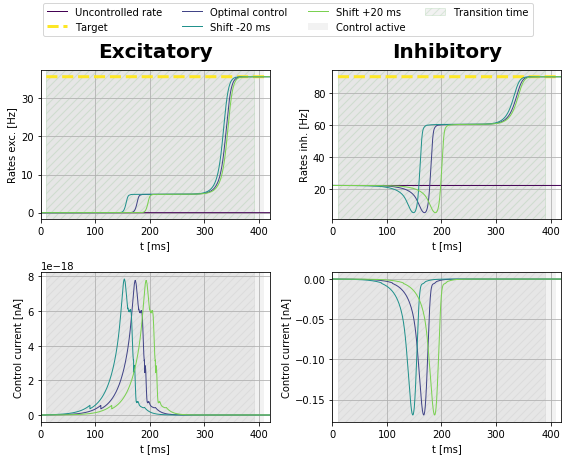

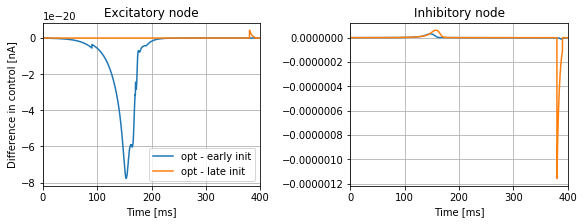

50 0.47500000000000014 0.6000000000000003
optimal cost =  5.006400036159537
shift by -20 ms cost =  5.006419838627336
shift by +20 ms cost =  5.006399972950262


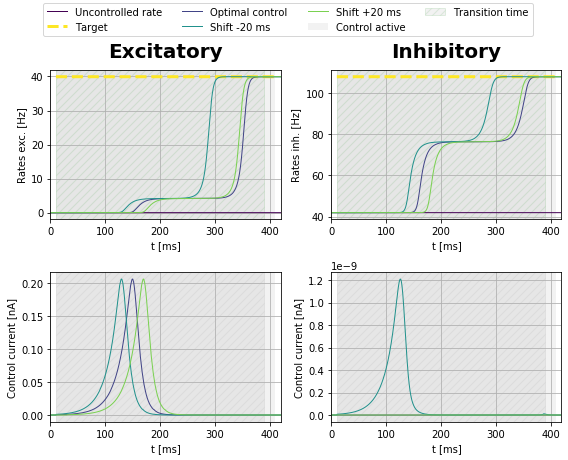

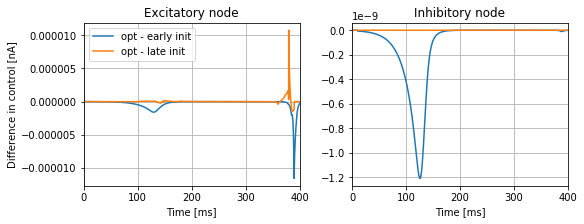

task2
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
optimal cost =  3.552056617539224
shift by -20 ms cost =  4.03964931084224
shift by +20 ms cost =  5.4488742944371635


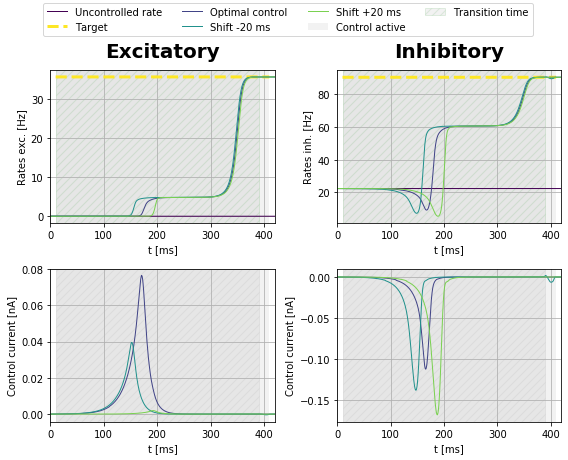

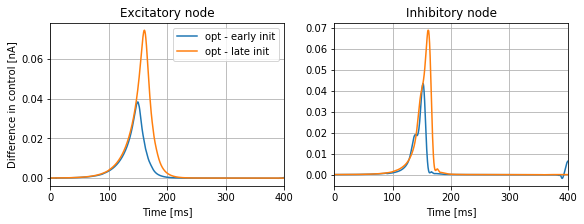

50 0.47500000000000014 0.6000000000000003
optimal cost =  11.019413730517254
shift by -20 ms cost =  12.532117965786844
shift by +20 ms cost =  11.721763115479503


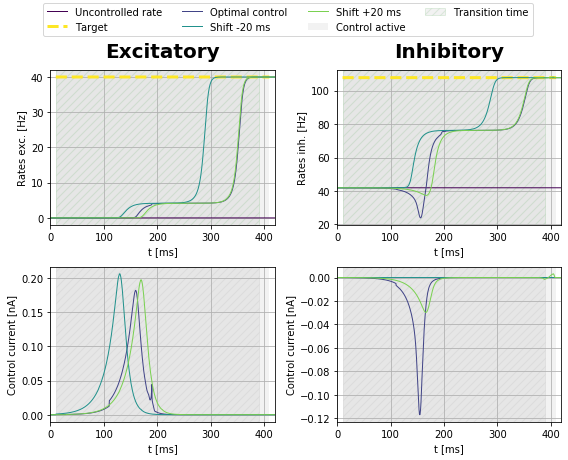

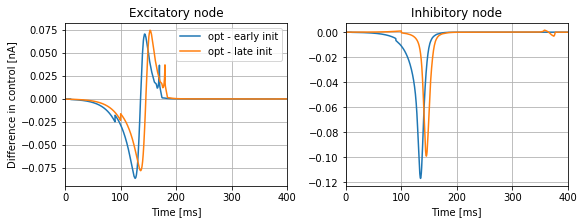

task3
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
optimal cost =  2.1463964678530347
shift by -20 ms cost =  2.146396197453777
shift by +20 ms cost =  2.146397285063518


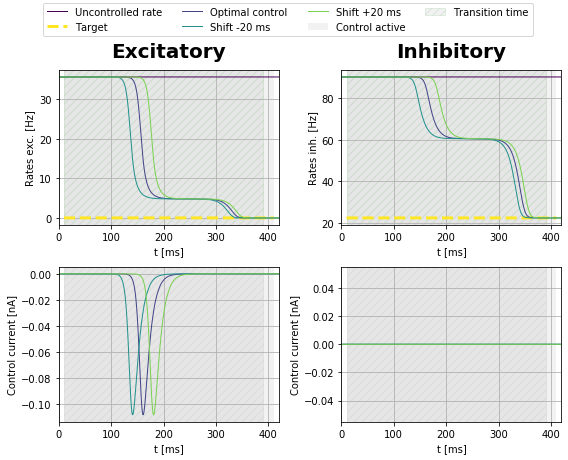

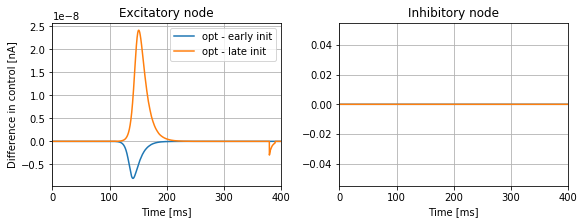

50 0.47500000000000014 0.6000000000000003
optimal cost =  2.657110907125297
shift by -20 ms cost =  2.6571108836736
shift by +20 ms cost =  2.6571110133437434


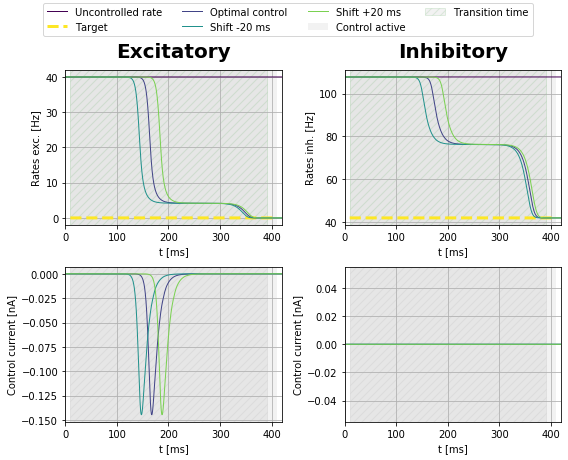

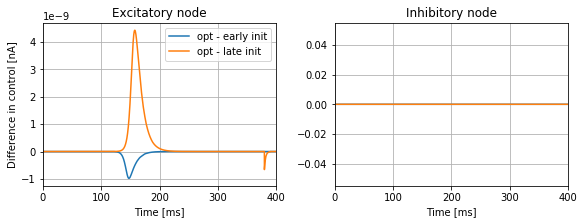

task4
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
20 0.4500000000000001 0.4750000000000002
optimal cost =  2.2901333542678253
shift by -20 ms cost =  2.290133066609165
shift by +20 ms cost =  2.290134108084192


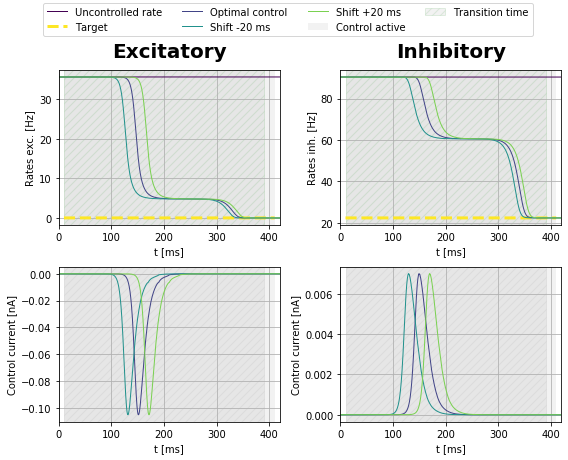

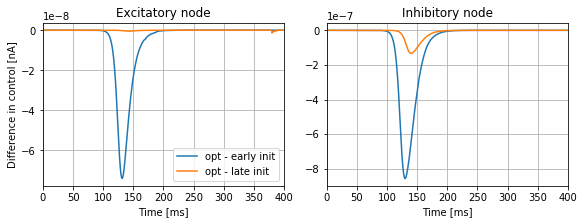

50 0.47500000000000014 0.6000000000000003
optimal cost =  3.521182185741615
shift by -20 ms cost =  3.5211797791379733
shift by +20 ms cost =  3.5211792864032954


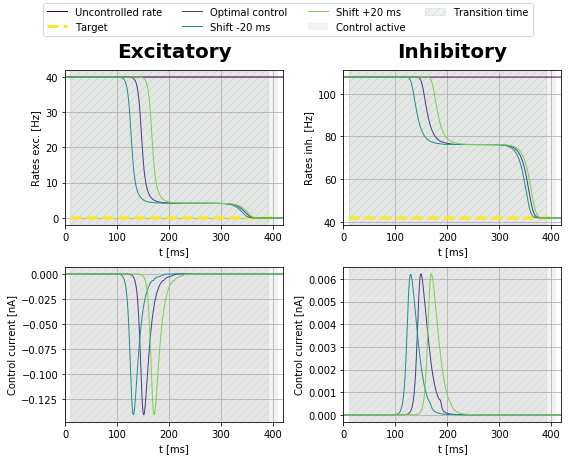

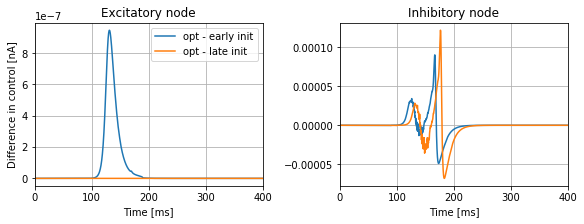

In [24]:
# FIG 4, 5
# task 1

ind0 = [20, 50]

cases_ = ['1', '2', '3', '4']
casepath_ = ['00121', '01121', '10121', '11121']
tasks_ = ['task1', 'task2', 'task3', 'task4']
dur = 400.

for c_ in range(len(cases_)):
    task = tasks_[c_]
    print(task)
    
    opt_cntrl_0 = [None] * len(ind0)
    cost_node_0 = [None] * len(ind0)

    opt_cntrl_min20 = [None] * len(ind0)
    cost_node_min20 = [None] * len(ind0)

    opt_cntrl_plus20 = [None] * len(ind0)
    cost_node_plus20 = [None] * len(ind0)

    target_ = [None] * len(ind0)
    initVars = [None] * len(ind0)

    readpath = '..' + os.sep
    control_data = data.read_control(readpath, cases_[c_])
    for i in range(len(ind0)):
        opt_cntrl_0[i] = control_data[2][ind0[i]]
        cost_node_0[i] = control_data[4][ind0[i]]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-20'
    control_data = data.read_control(readpath, '')
    for i in range(len(ind0)):
        opt_cntrl_min20[i] = control_data[2][ind0[i]]
        cost_node_min20[i] = control_data[4][ind0[i]]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+20'
    control_data = data.read_control(readpath, '')
    for i in range(len(ind0)):
        opt_cntrl_plus20[i] = control_data[2][ind0[i]]
        cost_node_plus20[i] = control_data[4][ind0[i]]

    data.set_parameters(aln)

    for i in range(len(ind0)):

        print("------- ", i, ext_exc[ind0[i]], ext_inh[ind0[i]])
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.
        
        maxI = 3.
        if c_ in [2,3]:
            maxI = -3.
            
        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        control0 = functions.step_control(aln, maxI_ = maxI)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -maxI)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for j in range(len(state_vars)):
            if aln.state[state_vars[j]].size == 1:
                init_state_vars[j] = aln.state[state_vars[j]][0]
            else:
                init_state_vars[j] = aln.state[state_vars[j]][0,-1]

        initVars[i] = init_state_vars

        aln.params.duration = dur

        target_[i] = aln.getZeroTarget()
        target_[i][:,0,:] = target_rates[0]
        target_[i][:,1,:] = target_rates[1]

    aln.params.duration = dur
    t_sim = aln.params.duration
    t_sim_pre = 10.
    t_sim_post = 10.

    for i in range(len(ind0)):
        aln.params.mue_ext_mean = ext_exc[ind0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind0[i]] * 5.

        print(ind0[i], ext_exc[ind0[i]], ext_inh[ind0[i]])
        setinit(initVars[i], aln)
        
        ind_cost = 2
        if c_ in [1,3]:
            ind_cost = 1
        print('optimal cost = ', cost_node_0[i][0][0,0] + sum(cost_node_0[i][ind_cost][0,:]))
        print('shift by -20 ms cost = ', cost_node_min20[i][0][0,0] + sum(cost_node_min20[i][ind_cost][0,:]))
        print('shift by +20 ms cost = ', cost_node_plus20[i][0][0,0] + sum(cost_node_plus20[i][ind_cost][0,:]))

        plotFunc.plot_control_current(aln, [opt_cntrl_0[i], opt_cntrl_min20[i], opt_cntrl_plus20[i]],
                            [cost_node_0[i], cost_node_min20[i], cost_node_plus20[i]],
                            [weights, weights, weights], t_sim, t_sim_pre, t_sim_post, initVars[i],
                            target_[i], path_=os.getcwd(), filename_ = 'FIG_3_' + str(i) + '_' + task, shading = False,
                            transition_time_ = 0.95, labels_ = ['Optimal control', 'Shift -20 ms', 'Shift +20 ms'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()

        fig3, ax = plt.subplots(1,2, constrained_layout=True, figsize = (8,3) )
        time_ = np.arange(0, dur + aln.params.dt, aln.params.dt )
        diff_min20 = np.zeros(( opt_cntrl_0[i][0,:,100:-100].shape ))
        diff_plus20 = diff_min20.copy()
        diff_min20[0,100:] = opt_cntrl_0[i][0,0,300:4201] - opt_cntrl_min20[i][0,0,100:4001]
        diff_min20[1,100:] = opt_cntrl_0[i][0,1,300:4201] - opt_cntrl_min20[i][0,1,100:4001]
        diff_plus20[0,:-100] = opt_cntrl_0[i][0,0,100:4001] - opt_cntrl_plus20[i][0,0,300:4201]
        diff_plus20[1,:-100] = opt_cntrl_0[i][0,1,100:4001] - opt_cntrl_plus20[i][0,1,300:4201]
        ax[0].plot(time_, diff_min20[0,:]/5., label='opt - early init')
        ax[1].plot(time_, diff_min20[1,:]/5.)
        ax[0].plot(time_, diff_plus20[0,:]/5., label='opt - late init')
        ax[1].plot(time_, diff_plus20[1,:]/5.)
        ax[0].legend()

        ax[0].set_xlim(0, dur)
        ax[1].set_xlim(0,dur)
        ax[0].set_title('Excitatory node')
        ax[1].set_title('Inhibitory node')
        ax[0].set_xlabel("Time [ms]")
        ax[1].set_xlabel("Time [ms]")
        ax[0].set_ylabel("Difference in control [nA]")
        plt.savefig( os.path.join(os.getcwd(), 'FIG_4_' + task + '_' + str(i)) )
        plt.show()

    # plot difference

task 1
case =  1
task 2
case =  2
task 3
case =  3
task 4
case =  4


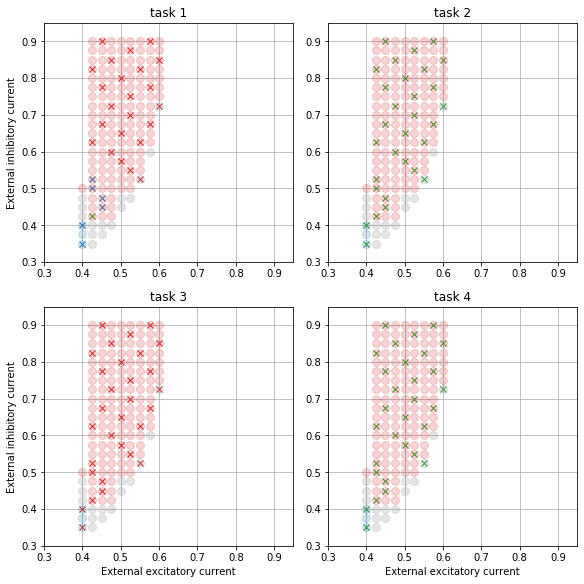

In [14]:
# fig 6, 7, 8, 9

fig7, ax = plt.subplots(2,2, constrained_layout=True, figsize = (8,8) )

titles = [r'task 1', r'task 2', 'task 3', 'task 4']

cases = ['1', '2', '3', '4']

alpha_val = 0.2

for k in range(len(cases)):
    print(titles[k])
    print("case = ", cases[k])
    readcase(cases[k])
    cost_index = np.zeros(( len(ext_exc), 4))
    
    ind_x = 0
    ind_y = 0
    
    if k == 1:
        ind_y = 1
    elif k == 2:
        ind_x = 1
    elif k == 3:
        ind_x = 1
        ind_y = 1

    for i in range(len(ext_exc)):
        cost_index[i,0] = i
        for j in range(len(exc_)):
            if exc_[j] == i:
                cost_index[i,1] = cost1[j][0][0][0] + cost1[j][2][0][0]
                if cost_index[i,1] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,1])
        for j in range(len(inh_)):
            if inh_[j] == i:
                cost_index[i,2] = cost2[j][0][0][0] + cost2[j][2][0][1]
                if cost_index[i,2] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,2])
        for j in range(len(both_c_)):
            if both_c_[j] == i:
                cost_index[i,3] = ( cost3[j][0][0][0] + cost3[j][2][0][0] + cost3[j][2][0][1] )
                if cost_index[i,3] > 200.:
                    print("large cost : ", i, ext_exc[i], ext_inh[i], cost_index[i,3])

    for i in range(cost_index.shape[0]):
        
        if cost_index[i,1] != 0. and cost_index[i,2] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,2] and cost_index[i,1] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,2] < cost_index[i,1] and cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
            elif cost_index[i,3] < cost_index[i,1] and cost_index[i,3] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,1] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,1] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,2] < cost_index[i,1]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0. and cost_index[i,3] != 0.:
            if cost_index[i,1] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
            elif cost_index[i,3] < cost_index[i,1]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
        elif cost_index[i,3] != 0. and cost_index[i,2] != 0.:
            if cost_index[i,3] < cost_index[i,2]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)
            elif cost_index[i,2] < cost_index[i,3]:
                ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,1] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=exc_red)
        elif cost_index[i,2] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=inh_blue)
        elif cost_index[i,3] != 0.:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'x', color=green)


        dist_x = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
        dist_y = data.dist_low(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)

        if (dist_x - dist_y) < - 1e-4:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=exc_red)
        elif (dist_x - dist_y) > 1e-4:
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color=inh_blue)
        else:
            #print("apparently same distance: ", i, dist_x, dist_y)
            ax[ind_x,ind_y].plot(ext_exc[i], ext_inh[i], 'o', alpha=alpha_val, markersize=8, color='grey')

    ax[ind_x,ind_y].set_xlim(0.3, 0.95)
    ax[ind_x,ind_y].set_ylim(0.3, 0.95)
    
    ax[ind_x,ind_y].set_title(titles[k])    
    
ax[1,0].set_xlabel("External excitatory current")
ax[1,1].set_xlabel("External excitatory current")
ax[0,0].set_ylabel("External inhibitory current")
ax[1,0].set_ylabel("External inhibitory current")
    
plt.savefig(os.path.join(os.getcwd(), 'FIG_6_7_8_9'))

#print(exc_, inh_, both_c_, no_c_)

-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
-------  0 0.4500000000000001 0.4750000000000002
-------  1 0.47500000000000014 0.6000000000000003
---------- 1 20
optimal cost =  3.3312300786170534


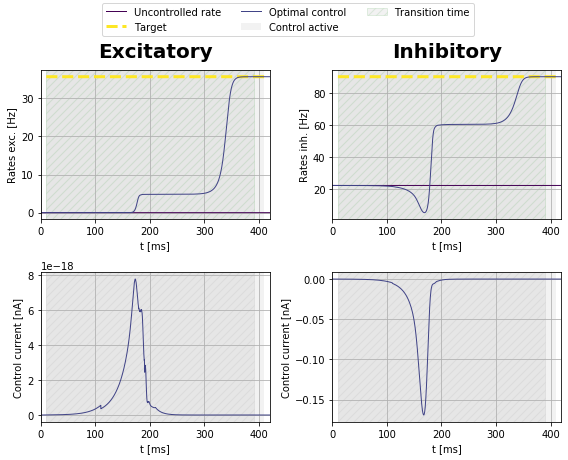

---------- 1 50
optimal cost =  0.4124201812003488


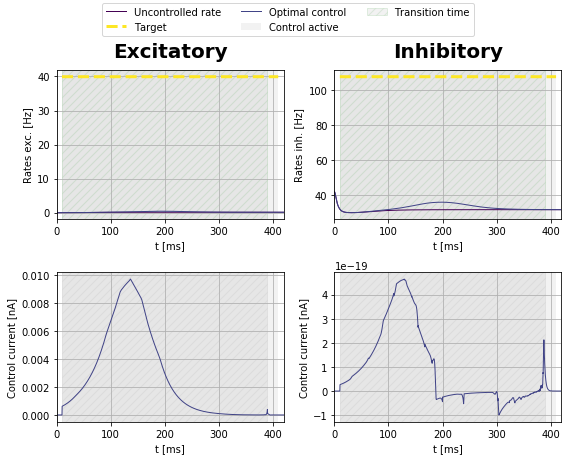

---------- 2 20
optimal cost =  3.552056617539224


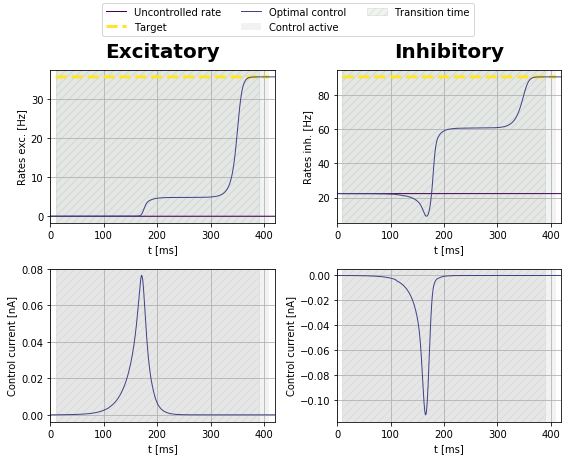

---------- 2 50
optimal cost =  0.07158776890389901


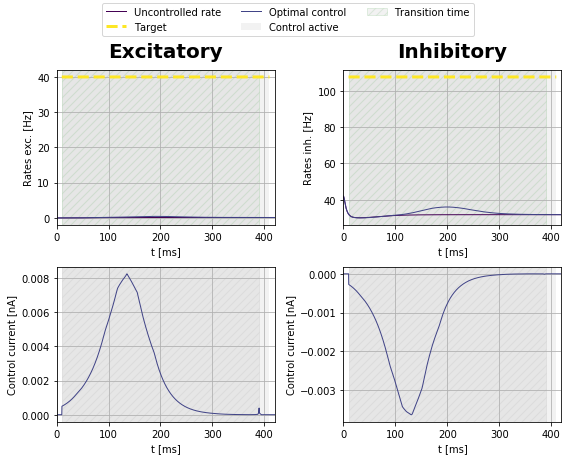

---------- 3 20
optimal cost =  2.1463964678530347


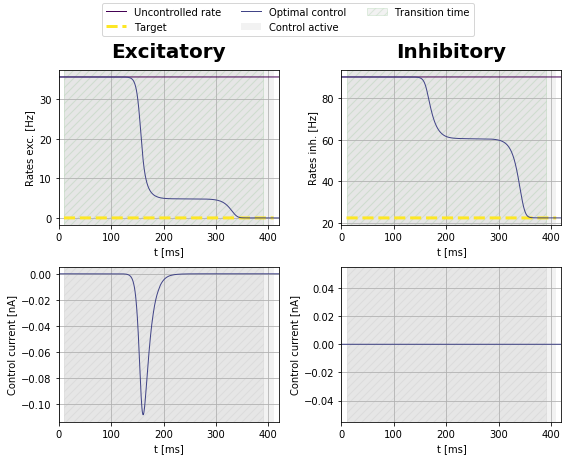

---------- 3 50
optimal cost =  4.893670096992012


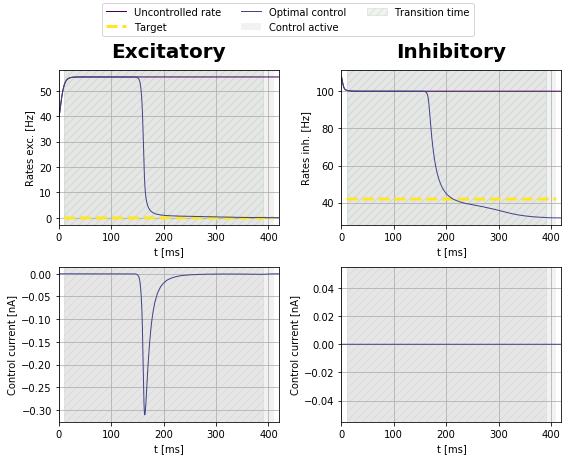

---------- 4 20
optimal cost =  2.2901333542678253


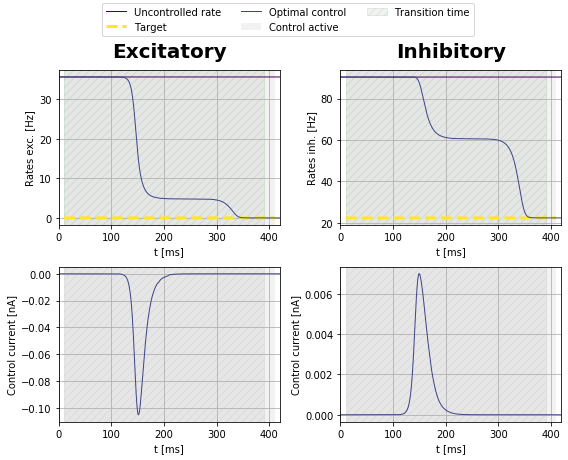

---------- 4 50
optimal cost =  12.792056729106188


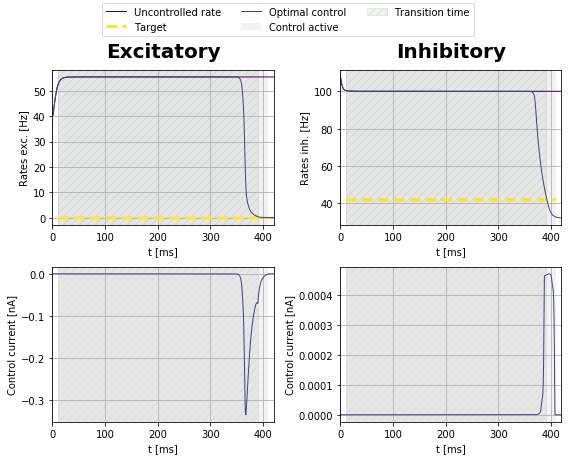

In [25]:
# FIG 8,9
weights = [1., 0., 1.]
ind_0 = [20,50]

case = ['1', '2', '3', '4']

opt_cntrl_0 = [None] * (len(ind_0) * len(case))
cost_node_0 = [None] * (len(ind_0) * len(case))

target_0 = [None] * (len(ind_0) * len(case))
initVars_0 = [None] * (len(ind_0) * len(case))

data.set_parameters(aln)

for j in range(len(case)):
    
    readpath = '..' + os.sep
    control_data = data.read_control(readpath, case[j])
    
    for i in range(len(ind_0)):
        opt_cntrl_0[j*2 + i] = control_data[2][ind[i]]
        cost_node_0[j*2 + i] = control_data[4][ind[i]]

        print("------- ", i, ext_exc[ind_0[i]], ext_inh[ind_0[i]])
        aln.params.mue_ext_mean = ext_exc[ind_0[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind_0[i]] * 5.

        aln.params.duration = 3000.
        control0 = aln.getZeroControl()
        maxI = 3.
        if j in [2,3]:
            maxI = -3
        control0 = functions.step_control(aln, maxI_ = maxI)
        aln.run(control=control0)

        target_rates = np.zeros((2))
        target_rates[0] = aln.rates_exc[0,-1] 
        target_rates[1] = aln.rates_inh[0,-1]

        control0 = functions.step_control(aln, maxI_ = -maxI)
        aln.run(control=control0)

        init_state_vars = np.zeros(( len(state_vars) ))
        for k in range(len(state_vars)):
            if aln.state[state_vars[k]].size == 1:
                init_state_vars[k] = aln.state[state_vars[k]][0]
            else:
                init_state_vars[k] = aln.state[state_vars[k]][0,-1]

        initVars_0[j*2 + i] = init_state_vars

        aln.params.duration = 400.

        target_0[j*2 + i] = aln.getZeroTarget()
        target_0[j*2 + i][:,0,:] = target_rates[0]
        target_0[j*2 + i][:,1,:] = target_rates[1]
    
aln.params.duration = 400.
t_sim = aln.params.duration
t_sim_pre = 10.
t_sim_post = 10.

names = ['FIG_8', 'FIG_9', 'FIG_10', 'FIG_11', 'FIG_12', 'FIG_13', 'FIG_14', 'FIG_15']

for j in range(len(case)):
    for i in range(len(ind_0)):
        aln.params.mue_ext_mean = ext_exc[ind[i]] * 5.
        aln.params.mui_ext_mean = ext_inh[ind[i]] * 5.

        filename = names[j*2 + i]
        
        print('----------', case[j], ind_0[i])
        ind_cost = 2
        if j in [1,3]:
            ind_cost = 1            
        print('optimal cost = ', cost_node_0[j*2 + i][0][0,0] + sum(cost_node_0[j*2 + i][ind_cost][0,:]))
        
        setinit(initVars_0[j*2 + i], aln)

        plotFunc.plot_control_current(aln, [opt_cntrl_0[j*2 + i]],
                            [cost_node_0[j*2 + i]],
                            [weights], t_sim, t_sim_pre, t_sim_post, initVars_0[j*2 + i],
                            target_0[j*2 + i], path_=os.getcwd(), filename_ = filename, shading = False,
                            transition_time_ = 0.95,
                            labels_ = ['Optimal control'],
                            precision_variables_ = [0], print_cost_ = False)
        plt.show()

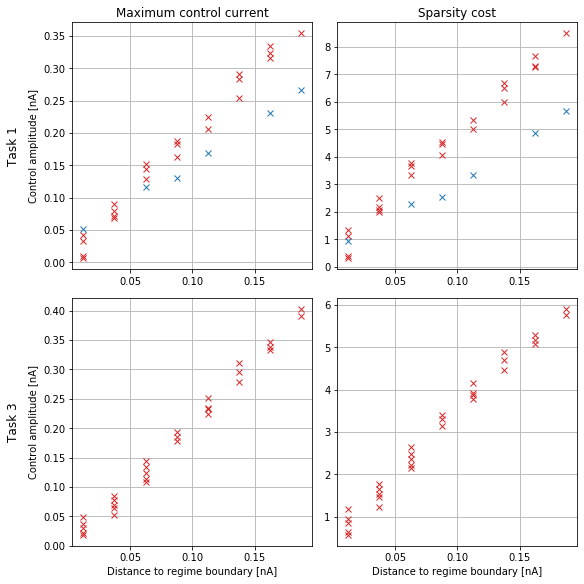

In [29]:
# FIG 16, 18

fig5, ax = plt.subplots(2, 2, constrained_layout=True, figsize = (8,8) )
    
readcase('1')
ax[0,0].plot(d_x, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[0,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[0,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
ax[0,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)

readcase('3')
ax[1,0].plot(d_x, np.abs(lenx_1), 'x', color=exc_red, markersize=6)
ax[1,0].plot(d_y, np.abs(leny_2), 'x', color=inh_blue, markersize=6)
ax[1,1].plot(d_x, cost_s_x, 'x', color=exc_red, markersize=6)
ax[1,1].plot(d_y, cost_s_y, 'x', color=inh_blue, markersize=6)

ax[1,0].set_xlabel("Distance to regime boundary [nA]")
ax[1,1].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Control amplitude [nA]")
ax[1,0].set_ylabel("Control amplitude [nA]")

cols = ['Maximum control current', 'Sparsity cost']
rows = ['Task 1', 'Task 3']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'FIG_16_18') )
plt.show()

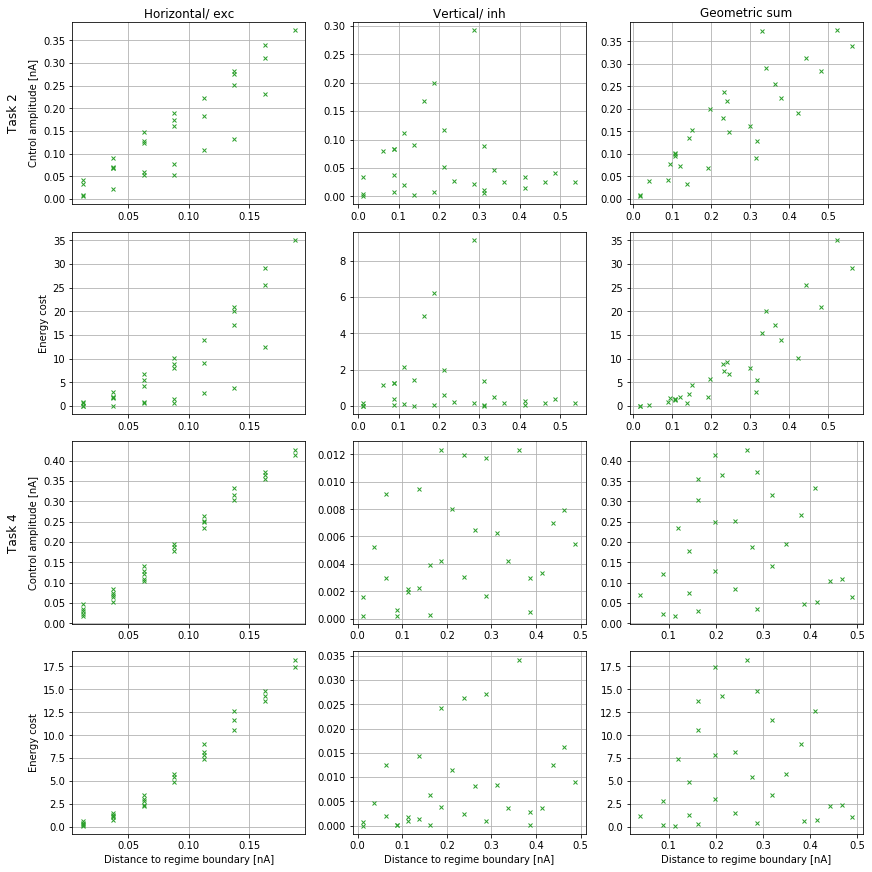

In [30]:
fig5b, ax = plt.subplots(4,3, constrained_layout=True, figsize = (12,12) )

color_array = [exc_red, inh_blue, green, exc_red, inh_blue, green]
range_1 = ['01000', '01010', '01020']
range_2 = ['01001', '01011', '01021']#, '01031', '01041', '01051']
range_3 = ['01100', '01110', '01120']
range_4 = ['01101', '01111', '01121']
range_5 = ['01131', '01141', '01151']

#########################################
readcase('2')
ax[0,0].plot(dx3, np.abs(lenx_3), 'x', color=green, markersize=4)
ax[0,1].plot(dy3, np.abs(leny_3), 'x', color=green, markersize=4)
ax[0,2].plot(d_xy, len3sqrt, 'x', color=green, markersize=4)
    
ax[1,0].plot(dx3, costx3, 'x', color=green, markersize=4)
ax[1,1].plot(dy3, costy3, 'x', color=green, markersize=4)
ax[1,2].plot(d_xy, cost_xy, 'x', color=green, markersize=4)

readcase('4')
ax[2,0].plot(dx3, np.abs(lenx_3), 'x', color=green, markersize=4)
ax[2,1].plot(dy3, np.abs(leny_3), 'x', color=green, markersize=4)
ax[2,2].plot(d_xy, len3sqrt, 'x', color=green, markersize=4)
    
ax[3,0].plot(dx3, costx3, 'x', color=green, markersize=4)
ax[3,1].plot(dy3, costy3, 'x', color=green, markersize=4)
ax[3,2].plot(d_xy, cost_xy, 'x', color=green, markersize=4)

ax[3,0].set_xlabel("Distance to regime boundary [nA]")
ax[3,1].set_xlabel("Distance to regime boundary [nA]")
ax[3,2].set_xlabel("Distance to regime boundary [nA]")
ax[0,0].set_ylabel("Cntrol amplitude [nA]")
ax[1,0].set_ylabel("Energy cost")
ax[2,0].set_ylabel("Control amplitude [nA]")
ax[3,0].set_ylabel("Energy cost")

cols = ['Horizontal/ exc', 'Vertical/ inh', 'Geometric sum']
rows = ['Task 2', '', 'Task 4', '']

pad = 5 # in points

for ax_, col in zip(ax[0], cols):
    ax_.annotate(col, xy=(0.5, 1), xytext=(0, pad),
                xycoords='axes fraction', textcoords='offset points',
                size='large', ha='center', va='baseline')

for ax_, row in zip(ax[:,0], rows):
    ax_.annotate(row, xy=(0, 0.5), xytext=(-ax_.yaxis.labelpad - pad, 0),
                xycoords=ax_.yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center', rotation=90)

plt.savefig( os.path.join(os.getcwd(), 'FIG_17_19.png') )
plt.show()